In [13]:
import pandas as pd
import os
import yfinance as yf
os.chdir('C:/Users/basleal/Desktop/tutorial/kaim-week-11')

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
ticker = ['TSLA','BND','SPY']
starttime = '2015-01-01'
endtime = '2025-01-31'
data = yf.download(ticker,start=starttime,end=endtime)

[*********************100%***********************]  3 of 3 completed


In [16]:
data

Price           Close                               High              \
Ticker            BND         SPY        TSLA        BND         SPY   
Date                                                                   
2015-01-02  62.573132  172.592896   14.620667  62.603416  173.811130   
2015-01-05  62.754810  169.475937   14.006000  62.777522  171.702341   
2015-01-06  62.936527  167.879593   14.085333  63.125799  170.316035   
2015-01-07  62.974373  169.971588   14.063333  63.050080  170.316054   
2015-01-08  62.875931  172.987717   14.041333  62.921354  173.206165   
...               ...         ...         ...        ...         ...   
2025-01-24  71.805977  607.969971  406.579987  71.855810  610.780029   
2025-01-27  72.184738  599.369995  397.149994  72.204677  599.690002   
2025-01-28  72.144867  604.520020  398.089996  72.154837  605.369995   
2025-01-29  72.104996  601.809998  389.100006  72.254510  604.130005   
2025-01-30  72.204674  605.039978  400.279999  72.294378  606.599976   

Price                         Low                               Open  \
Ticker            TSLA        BND         SPY        TSLA        BND   
Date                                                                   
2015-01-02   14.883333  62.398999  171.542703   14.217333  62.406572   
2015-01-05   14.433333  62.610962  169.165084   13.810667  62.641246   
2015-01-06   14.280000  62.860820  167.073039   13.614000  62.860820   
2015-01-07   14.318667  62.875954  168.770174   13.985333  62.944089   
2015-01-08   14.253333  62.815363  171.383032   14.000667  62.921354   
...                ...        ...         ...         ...        ...   
2025-01-24  418.880005  71.636531  606.799988  405.779999  71.766106   
2025-01-27  406.690002  72.025262  594.640015  389.000000  72.104996   
2025-01-28  400.589996  71.975421  597.250000  386.500000  72.154837   
2025-01-29  398.589996  71.935550  599.219971  384.480011  72.194707   
2025-01-30  412.500000  72.144864  600.719971  384.410004  72.224605   

Price                                Volume                       
Ticker             SPY        TSLA      BND        SPY      TSLA  
Date                                                              
2015-01-02  173.391052   14.858000  2218800  121465900  71466000  
2015-01-05  171.534312   14.303333  5820100  169632600  80527500  
2015-01-06  169.786733   14.004000  3887600  209151400  93928500  
2015-01-07  169.223851   14.223333  2433400  125346700  44526000  
2015-01-08  171.399826   14.187333  1873400  147217800  51637500  
...                ...         ...      ...        ...       ...  
2025-01-24  609.809998  414.450012  5555700   34604700  56427100  
2025-01-27  594.809998  394.799988  8621200   70361100  58125500  
2025-01-28  600.619995  396.910004  4424300   44433300  48910700  
2025-01-29  603.719971  395.209991  5780200   37177400  68033600  
2025-01-30  603.960022  410.779999  5622300   39281300  98092900  

[2535 rows x 15 columns]

now let's split our codes into test and train

In [17]:
from scripts.forecast import split_test_train
train,test = split_test_train(data)
train.shape

(2028, 15)

In [18]:
train.columns=['_'.join(col) for col in train.columns]#flatten multiIndex
train.columns

Index(['Close_BND', 'Close_SPY', 'Close_TSLA', 'High_BND', 'High_SPY',
       'High_TSLA', 'Low_BND', 'Low_SPY', 'Low_TSLA', 'Open_BND', 'Open_SPY',
       'Open_TSLA', 'Volume_BND', 'Volume_SPY', 'Volume_TSLA'],
      dtype='object')

In [19]:
test.columns= ['_'.join(col) for col in test.columns]
test.columns


Index(['Close_BND', 'Close_SPY', 'Close_TSLA', 'High_BND', 'High_SPY',
       'High_TSLA', 'Low_BND', 'Low_SPY', 'Low_TSLA', 'Open_BND', 'Open_SPY',
       'Open_TSLA', 'Volume_BND', 'Volume_SPY', 'Volume_TSLA'],
      dtype='object')

In [20]:
test.shape

(507, 15)

Train our data with arima and sarima

In [148]:
from scripts.forecast import arima_model,sarima_model

arima_m = arima_model(train,test)

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but i

In [149]:
bnd_model = arima_m['Close_BND']
spy_model = arima_m['Close_SPY']
tsla_model = arima_m['Close_TSLA']
print(bnd_model.summary())

                               SARIMAX Results                                
Dep. Variable:              Close_BND   No. Observations:                 2028
Model:                 ARIMA(0, 1, 2)   Log Likelihood                 104.169
Date:                Mon, 03 Mar 2025   AIC                           -202.339
Time:                        14:26:12   BIC                           -185.496
Sample:                             0   HQIC                          -196.159
                               - 2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0058      0.005      1.096      0.273      -0.005       0.016
ma.L2         -0.1073      0.010    -10.841      0.000      -0.127      -0.088
sigma2         0.0528      0.000    182.885      0.0

In [151]:
print(tsla_model.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_TSLA   No. Observations:                 2028
Model:                 ARIMA(0, 1, 2)   Log Likelihood               -6336.730
Date:                Mon, 03 Mar 2025   AIC                          12679.460
Time:                        14:26:37   BIC                          12696.303
Sample:                             0   HQIC                         12685.641
                               - 2028                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0382      0.012     -3.168      0.002      -0.062      -0.015
ma.L2          0.0163      0.010      1.572      0.116      -0.004       0.037
sigma2        30.4000      0.332     91.610      0.0

now we train s-arima

In [133]:
sarima_m=sarima_model(train,test)
bnd_smodel = sarima_m['Close_BND']
spy_smodel = sarima_m['Close_SPY']
tsla_smodel = sarima_m['Close_TSLA']
bnd_smodel.summary()

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but i

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                          Close_BND   No. Observations:                 2028
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                  69.853
Date:                            Mon, 03 Mar 2025   AIC                           -129.706
Time:                                    14:13:55   BIC                           -101.664
Sample:                                         0   HQIC                          -119.414
                                           - 2028                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6408      0.101      6.327      0.000       0.442       0.839
ma.L1         -0.6747      0.100     -6.740      0.000      -0.871      -0.479
ar.S.L12      -0.0951      0.019     -5.138      0.000      -0.131      -0.059
ma.S.L12      -0.9821      0.007   -148.125      0.000      -0.995      -0.969
sigma2         0.0535      0.000    152.100      0.000       0.053       0.054
===================================================================================
Ljung-Box (L1) (Q):                   3.63   Jarque-Bera (JB):            347370.70
Prob(Q):                              0.06   Prob(JB):                         0.00
Heteroskedasticity (H):               3.43   Skew:                            -2.18
Prob(H) (two-sided):                  0.00   Kurtosis:                        67.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [152]:
print(tsla_smodel.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Close_TSLA   No. Observations:                 2028
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -6330.182
Date:                            Mon, 03 Mar 2025   AIC                          12670.364
Time:                                    14:26:45   BIC                          12698.406
Sample:                                         0   HQIC                         12680.657
                                           - 2028                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5096      0.205     -2.485      0.013      -0.912      -0.108
ma.L1          0.4718      0.211   

let's forecast on our models 

In [113]:
#first let's prepare our test data for prediction
tickers_close=['Close_BND', 'Close_SPY', 'Close_TSLA']
test_ticker_tsla=test['Close_TSLA'].squeeze()
print(test_ticker_tsla)

Date
2023-01-24    143.889999
2023-01-25    144.429993
2023-01-26    160.270004
2023-01-27    177.899994
2023-01-30    166.660004
                 ...    
2025-01-24    406.579987
2025-01-27    397.149994
2025-01-28    398.089996
2025-01-29    389.100006
2025-01-30    400.279999
Name: Close_TSLA, Length: 507, dtype: float64


In [150]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
#let's forcast on our test_ticker
forecast_arima_tsla = tsla_model.forecast(steps=len(test_ticker_tsla))
#compute mae
mae_arima_tsla=mean_absolute_error(test_ticker_tsla,forecast_arima_tsla)
mse_arima_tsla=mean_squared_error(test_ticker_tsla,forecast_arima_tsla)
print(f'mae of our arima model is: {mae_arima_tsla}','\n',f'mse of our arima model is: {mse_arima_tsla}')


mae of our arima model is: 90.039668679466 
 mse of our arima model is: 12361.858633739439


c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


now let's calculate the mae for s-arima

In [138]:
forecast_sarima_tsla=tsla_smodel.forecast(steps=len(test_ticker_tsla))
#compute mae
mae_sarima_tsla=mean_absolute_error(test_ticker_tsla,forecast_sarima_tsla)
mse_sarima_tsla=mean_squared_error(test_ticker_tsla,forecast_sarima_tsla)
print(f'mae of our sarima model is: {mae_sarima_tsla}','\n',f'mse of our sarima model is: {mse_sarima_tsla}')

mae of our sarima model is: 73.91502999425657 
 mse of our sarima model is: 9161.436494269512


c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


now let's optimize our arima model with auto arima

In [30]:
#from scripts.forecast import auto_arima_model
#auto_arima_m=auto_arima_model(train)

In [144]:
from scripts.forecast import parameters
Best_pars = parameters(train,test)
Best_pars

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it 

Best Seasonal Order: (0, 0, 2, 12) with AIC=-186.4307881847651


In [141]:
from scripts.forecast import opt_sarima_model
optimized_m=opt_sarima_model(train,test)
bnd_opt_smodel = optimized_m['Close_BND']
tsla_opt_smodel = optimized_m['Close_TSLA']
print(tsla_opt_smodel)

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but i

In [143]:
forecast_opt_sarima=tsla_opt_smodel.forecast(steps=len(test_ticker_tsla))
#compute mae
mae_opt_sarima_tsla=mean_absolute_error(test_ticker_tsla,forecast_opt_sarima)
mse_opt_sarima_tsla=mean_squared_error(test_ticker_tsla,forecast_opt_sarima)
print(f'mae of our opt sarima model is: {mae_opt_sarima_tsla}','\n',f'mse of our opt sarima model is: {mse_opt_sarima_tsla}')

mae of our opt sarima model is: 73.76374321801516 
 mse of our opt sarima model is: 9136.961152363454


c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [99]:
print(forecast_opt_sarima)

2028    142.489735
2029    142.493071
2030    140.858276
2031    140.939068
2032    139.344017
           ...    
2530    110.335443
2531    110.278147
2532    110.220880
2533    110.163643
2534    110.106436
Name: predicted_mean, Length: 507, dtype: float64


now let's train our lstm model and try to see how we can optimize our prediction

In [165]:
print(train)

            Close_BND   Close_SPY  Close_TSLA   High_BND    High_SPY  \
Date                                                                   
2015-01-02  62.573132  172.592896   14.620667  62.603416  173.811130   
2015-01-05  62.754810  169.475937   14.006000  62.777522  171.702341   
2015-01-06  62.936527  167.879593   14.085333  63.125799  170.316035   
2015-01-07  62.974373  169.971588   14.063333  63.050080  170.316054   
2015-01-08  62.875931  172.987717   14.041333  62.921354  173.206165   
...               ...         ...         ...        ...         ...   
2023-01-17  68.806114  386.852692  131.490005  68.927200  389.245195   
2023-01-18  69.439484  380.745056  128.779999  69.541944  389.138200   
2023-01-19  69.299751  377.973236  127.169998  69.364952  380.346240   
2023-01-20  68.992401  385.014526  133.419998  69.104178  385.170139   
2023-01-23  68.824699  389.634216  143.750000  68.983044  391.598764   

             High_TSLA    Low_BND     Low_SPY    Low_TSLA   Ope

In [167]:
X_train = train['Close_BND'].values.reshape(-1, 1)  # Ensure it's 2D
y_train = train['Close_BND'].values  # Target variable

X_test = test['Close_BND'].values.reshape(-1,1)
y_test = test['Close_BND'].values

In [169]:
print(y_train)

[62.57313156 62.75481033 62.93652725 ... 69.29975128 68.99240112
 68.8246994 ]


In [170]:
from scripts.forecast import lstm_model
#train model
lstm_modell=lstm_model(X_train,y_train,X_test,y_test)


c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.1273 - val_loss: 0.0106
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0661 - val_loss: 0.0135
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0324 - val_loss: 0.0207
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0254 - val_loss: 0.0064
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0261 - val_loss: 0.0421
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0220 - val_loss: 0.0161
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0203 - val_loss: 0.0373
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0179 - val_loss: 0.0460
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0161 - val_loss: 0.0428
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0149 - val_loss: 0.0501
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0134 - val_loss: 0.0477
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0128 - v

Now we evaluate our model

In [173]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))  
X_test_scaled = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))  
y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.reshape(-1, 1))


In [174]:
loss=lstm_modell.evaluate(X_test_scaled,y_test_scaled)
print(f'test loss: {loss}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0497 
test loss: 0.05507063493132591


now let's predict

In [186]:
predicted = lstm_modell.predict(X_test_scaled)
predicted_actual = scaler.inverse_transform(predicted)
predicted_actual

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


array([[65.27087 ],
       [65.33831 ],
       [65.23338 ],
       [65.17354 ],
       [65.016716],
       [65.27087 ],
       [65.62933 ],
       [65.667114],
       [65.17031 ],
       [64.826614],
       [64.75224 ],
       [64.84898 ],
       [64.62604 ],
       [64.39684 ],
       [64.54458 ],
       [64.35998 ],
       [64.2423  ],
       [64.037186],
       [64.15425 ],
       [63.6955  ],
       [63.811436],
       [64.00066 ],
       [63.709976],
       [63.796913],
       [63.811436],
       [63.502968],
       [63.39509 ],
       [63.792522],
       [63.669147],
       [63.611233],
       [63.56789 ],
       [63.74167 ],
       [64.3716  ],
       [64.802124],
       [64.46031 ],
       [65.0189  ],
       [64.75739 ],
       [65.15391 ],
       [64.91413 ],
       [64.76484 ],
       [65.25166 ],
       [65.37968 ],
       [65.49289 ],
       [64.91413 ],
       [64.81704 ],
       [64.87677 ],
       [64.95151 ],
       [65.2366  ],
       [65.47311 ],
       [65.700615],


now let's plot and see the actual vs the predicted values

In [197]:
print("Test Set Index:", test_ticker_tsla.index)
print("SARIMA Forecast Index:", forecast_sarima_tsla.index)
forecast_sarima_tsla.index = test_ticker_tsla.index
forecast_arima_tsla.index=test_ticker_tsla.index
forecast_opt_sarima.index = test_ticker_tsla.index
#predicted_actual = pd.Series(predicted_actual.flatten(), index=test_ticker_tsla.index)
#y_test=pd.Series(y_test.flatten(),index=test_ticker_tsla.index)
y_train=pd.Series(y_train.flatten(),index=train.index)
print(len(y_train))

Test Set Index: DatetimeIndex(['2023-01-24', '2023-01-25', '2023-01-26', '2023-01-27',
               '2023-01-30', '2023-01-31', '2023-02-01', '2023-02-02',
               '2023-02-03', '2023-02-06',
               ...
               '2025-01-16', '2025-01-17', '2025-01-21', '2025-01-22',
               '2025-01-23', '2025-01-24', '2025-01-27', '2025-01-28',
               '2025-01-29', '2025-01-30'],
              dtype='datetime64[ns]', name='Date', length=507, freq=None)
SARIMA Forecast Index: DatetimeIndex(['2023-01-24', '2023-01-25', '2023-01-26', '2023-01-27',
               '2023-01-30', '2023-01-31', '2023-02-01', '2023-02-02',
               '2023-02-03', '2023-02-06',
               ...
               '2025-01-16', '2025-01-17', '2025-01-21', '2025-01-22',
               '2025-01-23', '2025-01-24', '2025-01-27', '2025-01-28',
               '2025-01-29', '2025-01-30'],
              dtype='datetime64[ns]', name='Date', length=507, freq=None)
2028


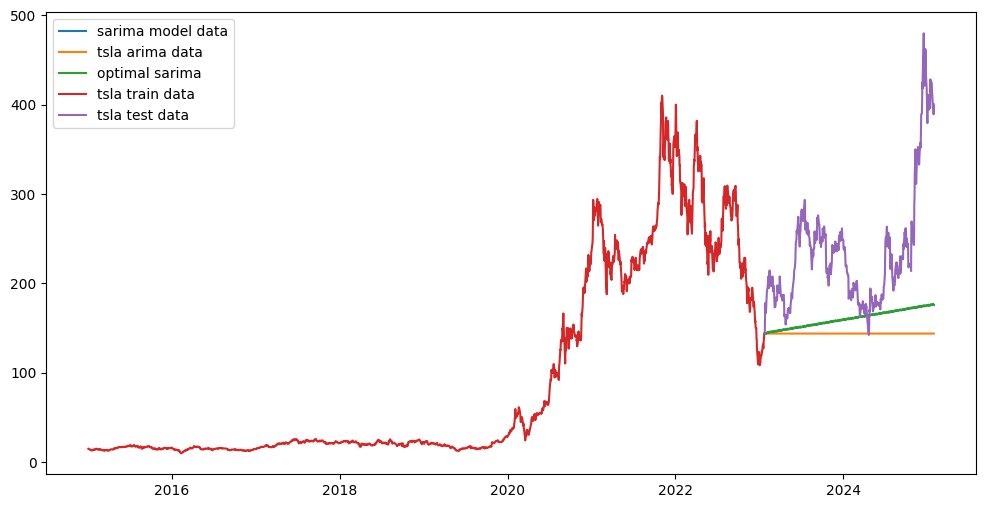

In [206]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(forecast_sarima_tsla,label='sarima model data')
plt.plot(forecast_arima_tsla,label='tsla arima data')
plt.plot(forecast_opt_sarima,label = 'optimal sarima')
plt.plot(train['Close_TSLA'],label='tsla train data')
plt.plot(test_ticker_tsla,label='tsla test data')
plt.legend()
plt.show()

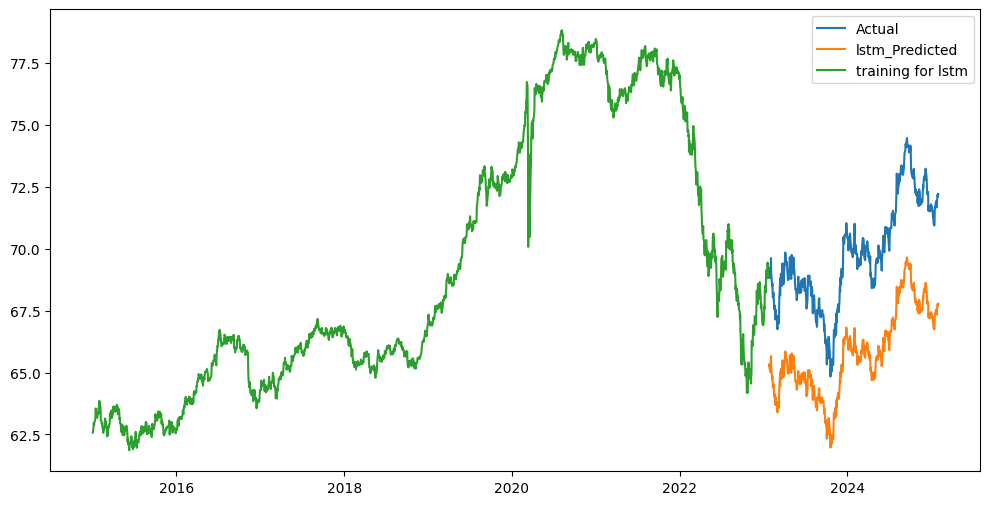

In [205]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(predicted_actual, label='lstm_Predicted')
plt.plot(y_train,label='training for lstm')
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

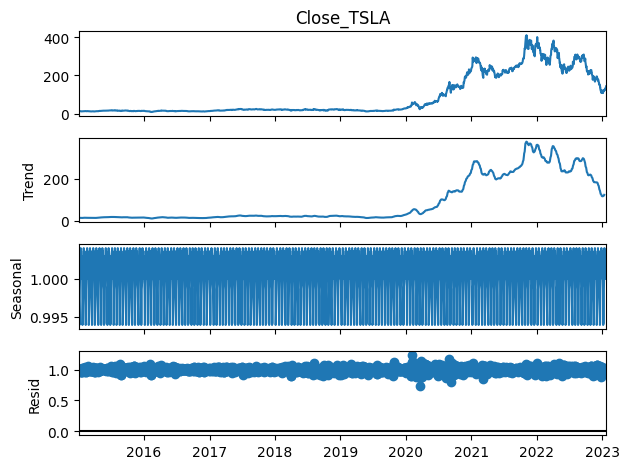

In [158]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(train['Close_TSLA'], model='multiplicative', period=12)
plt.figure(figsize=(12,6))
result.plot()

plt.show()